# 03 - TF-IDF Vectorization

Split 70/15/15, fit vectorizer only on train, evaluate TF-IDF configs, save final vectorizer and matrices.
Results are saved to `reports/03_vectorization/`.


In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORT_DIR = ROOT / "reports" / "03_vectorization"
MODEL_DIR = ROOT / "models"
DATA_DIR = ROOT / "data"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")


In [2]:
data_path = ROOT / "data" / "processed" / "preprocessed_isot_full.csv"
if not data_path.exists():
    data_path = ROOT / "data" / "preprocessed_isot_full.csv"

if not data_path.exists():
    raise FileNotFoundError("Run notebooks/01_preprocessing.ipynb before vectorization.")

df = pd.read_csv(data_path).dropna(subset=["processed_text", "label"]).reset_index(drop=True)
X = df["processed_text"].astype(str)
y = df["label"].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
print("Train labels:")
print(y_train.value_counts().sort_index())


Train size: 27055 | Val size: 5798 | Test size: 5798
Train labels:
label
0    14836
1    12219
Name: count, dtype: int64


In [3]:
configs = [
    {"max_features": max_features, "ngram_range": ngram_range}
    for max_features in [3000, 5000, 10000]
    for ngram_range in [(1, 1), (1, 2)]
]

rows = []
for cfg in configs:
    vectorizer = TfidfVectorizer(
        max_features=cfg["max_features"],
        ngram_range=cfg["ngram_range"],
    )
    X_train_cfg = vectorizer.fit_transform(X_train)
    X_val_cfg = vectorizer.transform(X_val)

    clf = MultinomialNB(alpha=0.1)
    clf.fit(X_train_cfg, y_train)
    y_pred = clf.predict(X_val_cfg)

    rows.append({
        "max_features": cfg["max_features"],
        "ngram_range": str(cfg["ngram_range"]),
        "val_accuracy": accuracy_score(y_val, y_pred),
        "val_f1_weighted": f1_score(y_val, y_pred, average="weighted"),
        "n_features_actual": len(vectorizer.get_feature_names_out()),
    })

results = pd.DataFrame(rows).sort_values(
    ["val_accuracy", "val_f1_weighted"], ascending=False
).reset_index(drop=True)
results.to_csv(REPORT_DIR / "tfidf_config_results.csv", index=False)
display(results)

best = results.iloc[0].to_dict()
print("Best TF-IDF config:", best)


,max_features,ngram_range,val_accuracy,val_f1_weighted,n_features_actual
0,10000,"(1, 2)",0.951535,0.951554,10000
1,5000,"(1, 2)",0.946533,0.946540,5000
2,10000,"(1, 1)",0.938255,0.938291,10000
3,3000,"(1, 2)",0.937047,0.937071,3000
4,5000,"(1, 1)",0.935150,0.935177,5000
5,3000,"(1, 1)",0.928769,0.928791,3000


Best TF-IDF config: {'max_features': 10000, 'ngram_range': '(1, 2)', 'val_accuracy': 0.9515350120731286, 'val_f1_weighted': 0.9515544602565377, 'n_features_actual': 10000}


/var/folders/bt/x0xylfv90fz2hms4m1hdtcy80000gn/T/ipykernel_52440/818436216.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="config", y="val_accuracy", palette="mako")


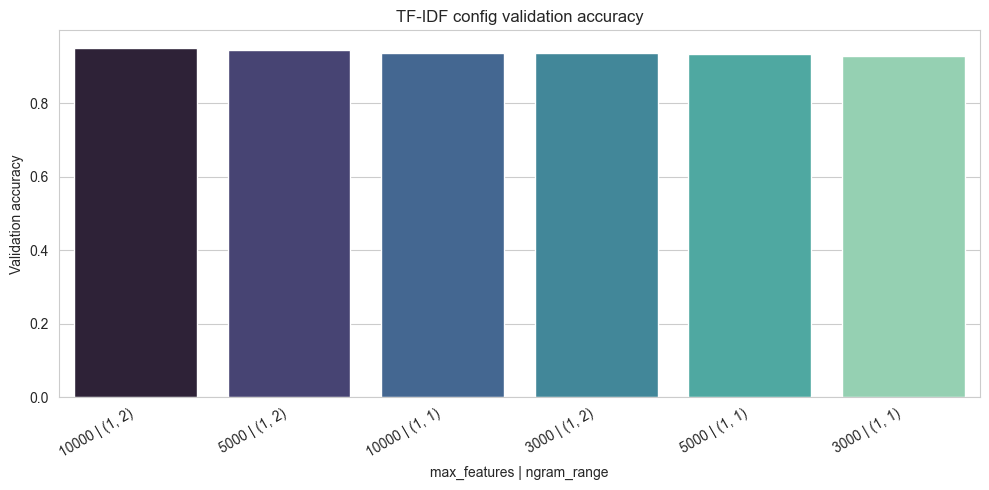

In [4]:
plt.figure(figsize=(10, 5))
plot_df = results.copy()
plot_df["config"] = plot_df["max_features"].astype(str) + " | " + plot_df["ngram_range"]
sns.barplot(data=plot_df, x="config", y="val_accuracy", palette="mako")
plt.xticks(rotation=30, ha="right")
plt.title("TF-IDF config validation accuracy")
plt.xlabel("max_features | ngram_range")
plt.ylabel("Validation accuracy")
plt.tight_layout()
plt.savefig(REPORT_DIR / "tfidf_config_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()


In [5]:
best_max_features = int(best["max_features"])
best_ngram_range = tuple(int(x) for x in best["ngram_range"].strip("()").split(",") if x.strip())

vectorizer = TfidfVectorizer(max_features=best_max_features, ngram_range=best_ngram_range)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

joblib.dump(vectorizer, MODEL_DIR / "tfidf_vectorizer.pkl")
joblib.dump(X_train_tfidf, DATA_DIR / "X_train_tfidf.pkl")
joblib.dump(X_val_tfidf, DATA_DIR / "X_val_tfidf.pkl")
joblib.dump(X_test_tfidf, DATA_DIR / "X_test_tfidf.pkl")
joblib.dump(y_train, DATA_DIR / "y_train.pkl")
joblib.dump(y_val, DATA_DIR / "y_val.pkl")
joblib.dump(y_test, DATA_DIR / "y_test.pkl")

summary = {
    "train_size": int(len(X_train)),
    "val_size": int(len(X_val)),
    "test_size": int(len(X_test)),
    "best_config": {
        "max_features": best_max_features,
        "ngram_range": list(best_ngram_range),
        "val_accuracy": float(best["val_accuracy"]),
        "val_f1_weighted": float(best["val_f1_weighted"]),
    },
    "train_shape": list(X_train_tfidf.shape),
    "val_shape": list(X_val_tfidf.shape),
    "test_shape": list(X_test_tfidf.shape),
}
with open(REPORT_DIR / "split_vectorization_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved vectorizer:", MODEL_DIR / "tfidf_vectorizer.pkl")
print("Saved TF-IDF matrices and labels in:", DATA_DIR)
print(summary)


Saved vectorizer: /Users/duyhung/Desktop/CHUNG/HUST/Fake-News-Detection/models/tfidf_vectorizer.pkl
Saved TF-IDF matrices and labels in: /Users/duyhung/Desktop/CHUNG/HUST/Fake-News-Detection/data
{'train_size': 27055, 'val_size': 5798, 'test_size': 5798, 'best_config': {'max_features': 10000, 'ngram_range': [1, 2], 'val_accuracy': 0.9515350120731286, 'val_f1_weighted': 0.9515544602565377}, 'train_shape': [27055, 10000], 'val_shape': [5798, 10000], 'test_shape': [5798, 10000]}
